In [1]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from xgboost import XGBClassifier
from sklearn.utils import resample
import warnings

import sys
sys.path.append('..')

from software.raw_data import get_raw_test_data, get_raw_train_data
from software.torch_lr import TorchLR

In [2]:
def get_metrics(y_true, y_pred, y_prob):
    """Funkcja pomocnicza do obliczania wszystkich metryk."""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0)
    }

In [3]:
NUM_LAYERS = 24
RUNS_PER_LAYER = 10
OUTPUT_DIR_DEBIASED = "../data/torch_lr_debiased_concepts_detection_results"
os.makedirs(OUTPUT_DIR_DEBIASED, exist_ok=True)

In [4]:
def get_debiased_datasets(X_train, y_train, X_test):
    """Oblicza CAV (LR i DM) i zwraca dane wyczyszczone trzema metodami:

    - 'lr':     ortogonalne rzutowanie CAV-LR (projection to null space)
    - 'dm':     ortogonalne rzutowanie CAV-DM
    - 'pclarc': Projective Class Artifact Compensation (Pahde, Anders, Becking,
                Samek, Lapuschkin 2022). Zamiast zerować kierunek CAV, PRZESUWA
                wszystkie próbki wzdłuż CAV tak, żeby ich projekcja = średnia
                projekcja klasy "bez okularów" (y=0). Efektywnie: rozkłady obu
                klas wzdłuż CAV nakładają się na siebie.
                Używa CAV-LR (standardowy wariant P-ClArC).

    Formuła P-ClArC: x_new = x - (x·v - t) * v
      gdzie v = znormalizowany CAV, t = (X[y==0] @ v).mean()
    """
    lr_finder = TorchLR(C=0.1, max_iter=200, tol=1e-5, device='cuda', random_state=42)
    lr_finder.fit(X_train, y_train)
    cav_lr = lr_finder.coef_[0]
    cav_lr_norm = cav_lr / (np.linalg.norm(cav_lr) + 1e-10)

    cav_dm = X_train[y_train == 1].mean(axis=0) - X_train[y_train == 0].mean(axis=0)
    cav_dm_norm = cav_dm / (np.linalg.norm(cav_dm) + 1e-10)

    def project_out(X, v):
        return X - np.dot(X, v).reshape(-1, 1) * v

    def pclarc_shift(X, v, target):
        projections = X @ v  # (n,) skalar na próbkę
        return X - ((projections - target).reshape(-1, 1)) * v

    # target = średnia projekcja klasy "bez okularów" na kierunek CAV-LR
    target_lr = (X_train[y_train == 0] @ cav_lr_norm).mean()

    return {
        'lr': (project_out(X_train, cav_lr_norm), project_out(X_test, cav_lr_norm)),
        'dm': (project_out(X_train, cav_dm_norm), project_out(X_test, cav_dm_norm)),
        'pclarc': (pclarc_shift(X_train, cav_lr_norm, target_lr),
                   pclarc_shift(X_test, cav_lr_norm, target_lr)),
    }

In [5]:
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

for layer in tqdm(range(NUM_LAYERS), desc="Warstwy"):
    layer_results = []

    train_df = get_raw_train_data(layer)
    test_df = get_raw_test_data(layer)

    X_train_raw = train_df.iloc[:, :-1].values
    y_train_raw = train_df.iloc[:, -1].astype(int).values
    X_test_raw = test_df.iloc[:, :-1].values
    y_test_raw = test_df.iloc[:, -1].astype(int).values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    run_pbar = tqdm(range(RUNS_PER_LAYER), desc=f" L{layer:02d} Runs", leave=False)
    for run_id in run_pbar:

        X_train_b, y_train_b = resample(
            X_train_scaled, y_train_raw,
            replace=True, n_samples=len(y_train_raw),
            random_state=run_id, stratify=y_train_raw
        )

        debiased_sets = get_debiased_datasets(X_train_b, y_train_b, X_test_scaled)

        for method, (X_tr_clean, X_te_clean) in debiased_sets.items():

            models = {
                'LogisticRegression': TorchLR(
                    C=0.1, max_iter=200, tol=1e-5, device='cuda', random_state=run_id
                ),
                'XGBoost': XGBClassifier(
                    n_estimators=100, max_depth=4, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    tree_method='hist', device='cuda',  # <- GPU (RTX 4090)
                    random_state=run_id, eval_metric='logloss',
                )
            }

            for model_name, model in models.items():
                model.fit(X_tr_clean, y_train_b)

                tr_metrics = get_metrics(y_train_b, model.predict(X_tr_clean), model.predict_proba(X_tr_clean)[:, 1])
                te_metrics = get_metrics(y_test_raw, model.predict(X_te_clean), model.predict_proba(X_te_clean)[:, 1])

                layer_results.append({
                    'layer_id': layer,
                    'run_id': run_id,
                    'debias_method': method,
                    'model': model_name,
                    **{f'train_{k}': v for k, v in tr_metrics.items()},
                    **{f'test_{k}': v for k, v in te_metrics.items()}
                })

    pd.DataFrame(layer_results).to_csv(f"{OUTPUT_DIR_DEBIASED}/{layer:02d}_torch_lr_debiased_results.csv", index=False)

Warstwy:   0%|          | 0/24 [00:00<?, ?it/s]

 L00 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L01 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L02 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L03 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

...

 L19 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L20 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L21 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L22 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

 L23 Runs:   0%|          | 0/10 [00:00<?, ?it/s]

# Visualization

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

In [7]:
OUTPUT_DIR = "../data/torch_lr_debiased_concepts_detection_results/"
all_files = glob.glob(os.path.join(OUTPUT_DIR, "*_torch_lr_debiased_results.csv"))

In [8]:
li = []
for filename in all_files:
    df = pd.read_csv(filename)
    li.append(df)

In [9]:
df_all = pd.concat(li, axis=0, ignore_index=True).sort_values('layer_id')

In [10]:
df_all.head(1)

,layer_id,run_id,debias_method,model,train_accuracy,train_roc_auc,train_f1,train_recall,train_precision,test_accuracy,test_roc_auc,test_f1,test_recall,test_precision
1392,0,2,lr,LogisticRegression,0.753348,0.837957,0.752242,0.748884,0.755631,0.609375,0.648987,0.618321,0.632812,0.604478


In [11]:
import pandas as pd

metric_cols = [c for c in df_all.columns if 'train_' in c or 'test_' in c]
metric_cols = [col for col in metric_cols if col.split('_')[1] not in ['recall', 'precision']]
id_vars = ['layer_id', 'model', 'run_id', 'debias_method'] 

df_melted = df_all.melt(id_vars=id_vars, value_vars=metric_cols, 
                        var_name='metric_type', value_name='score')

# Rozdzielamy informacje o zbiorze (train/test) i nazwie metryki
df_melted['subset'] = df_melted['metric_type'].apply(lambda x: x.split('_')[0])
df_melted['metric'] = df_melted['metric_type'].apply(lambda x: x.split('_')[1])

metrics = list(df_melted['metric'].unique())
models = list(df_melted['model'].unique())

In [12]:
df_melted = df_all.melt(id_vars=id_vars, value_vars=metric_cols, 
                        var_name='metric_type', value_name='score')

# Rozdzielamy informacje o zbiorze (train/test) i nazwie metryki
df_melted['subset'] = df_melted['metric_type'].apply(lambda x: x.split('_')[0])
df_melted['metric'] = df_melted['metric_type'].apply(lambda x: x.split('_')[1])

In [13]:
from warnings import filterwarnings

filterwarnings('ignore')

In [14]:
metrics = list(df_melted['metric'].unique())

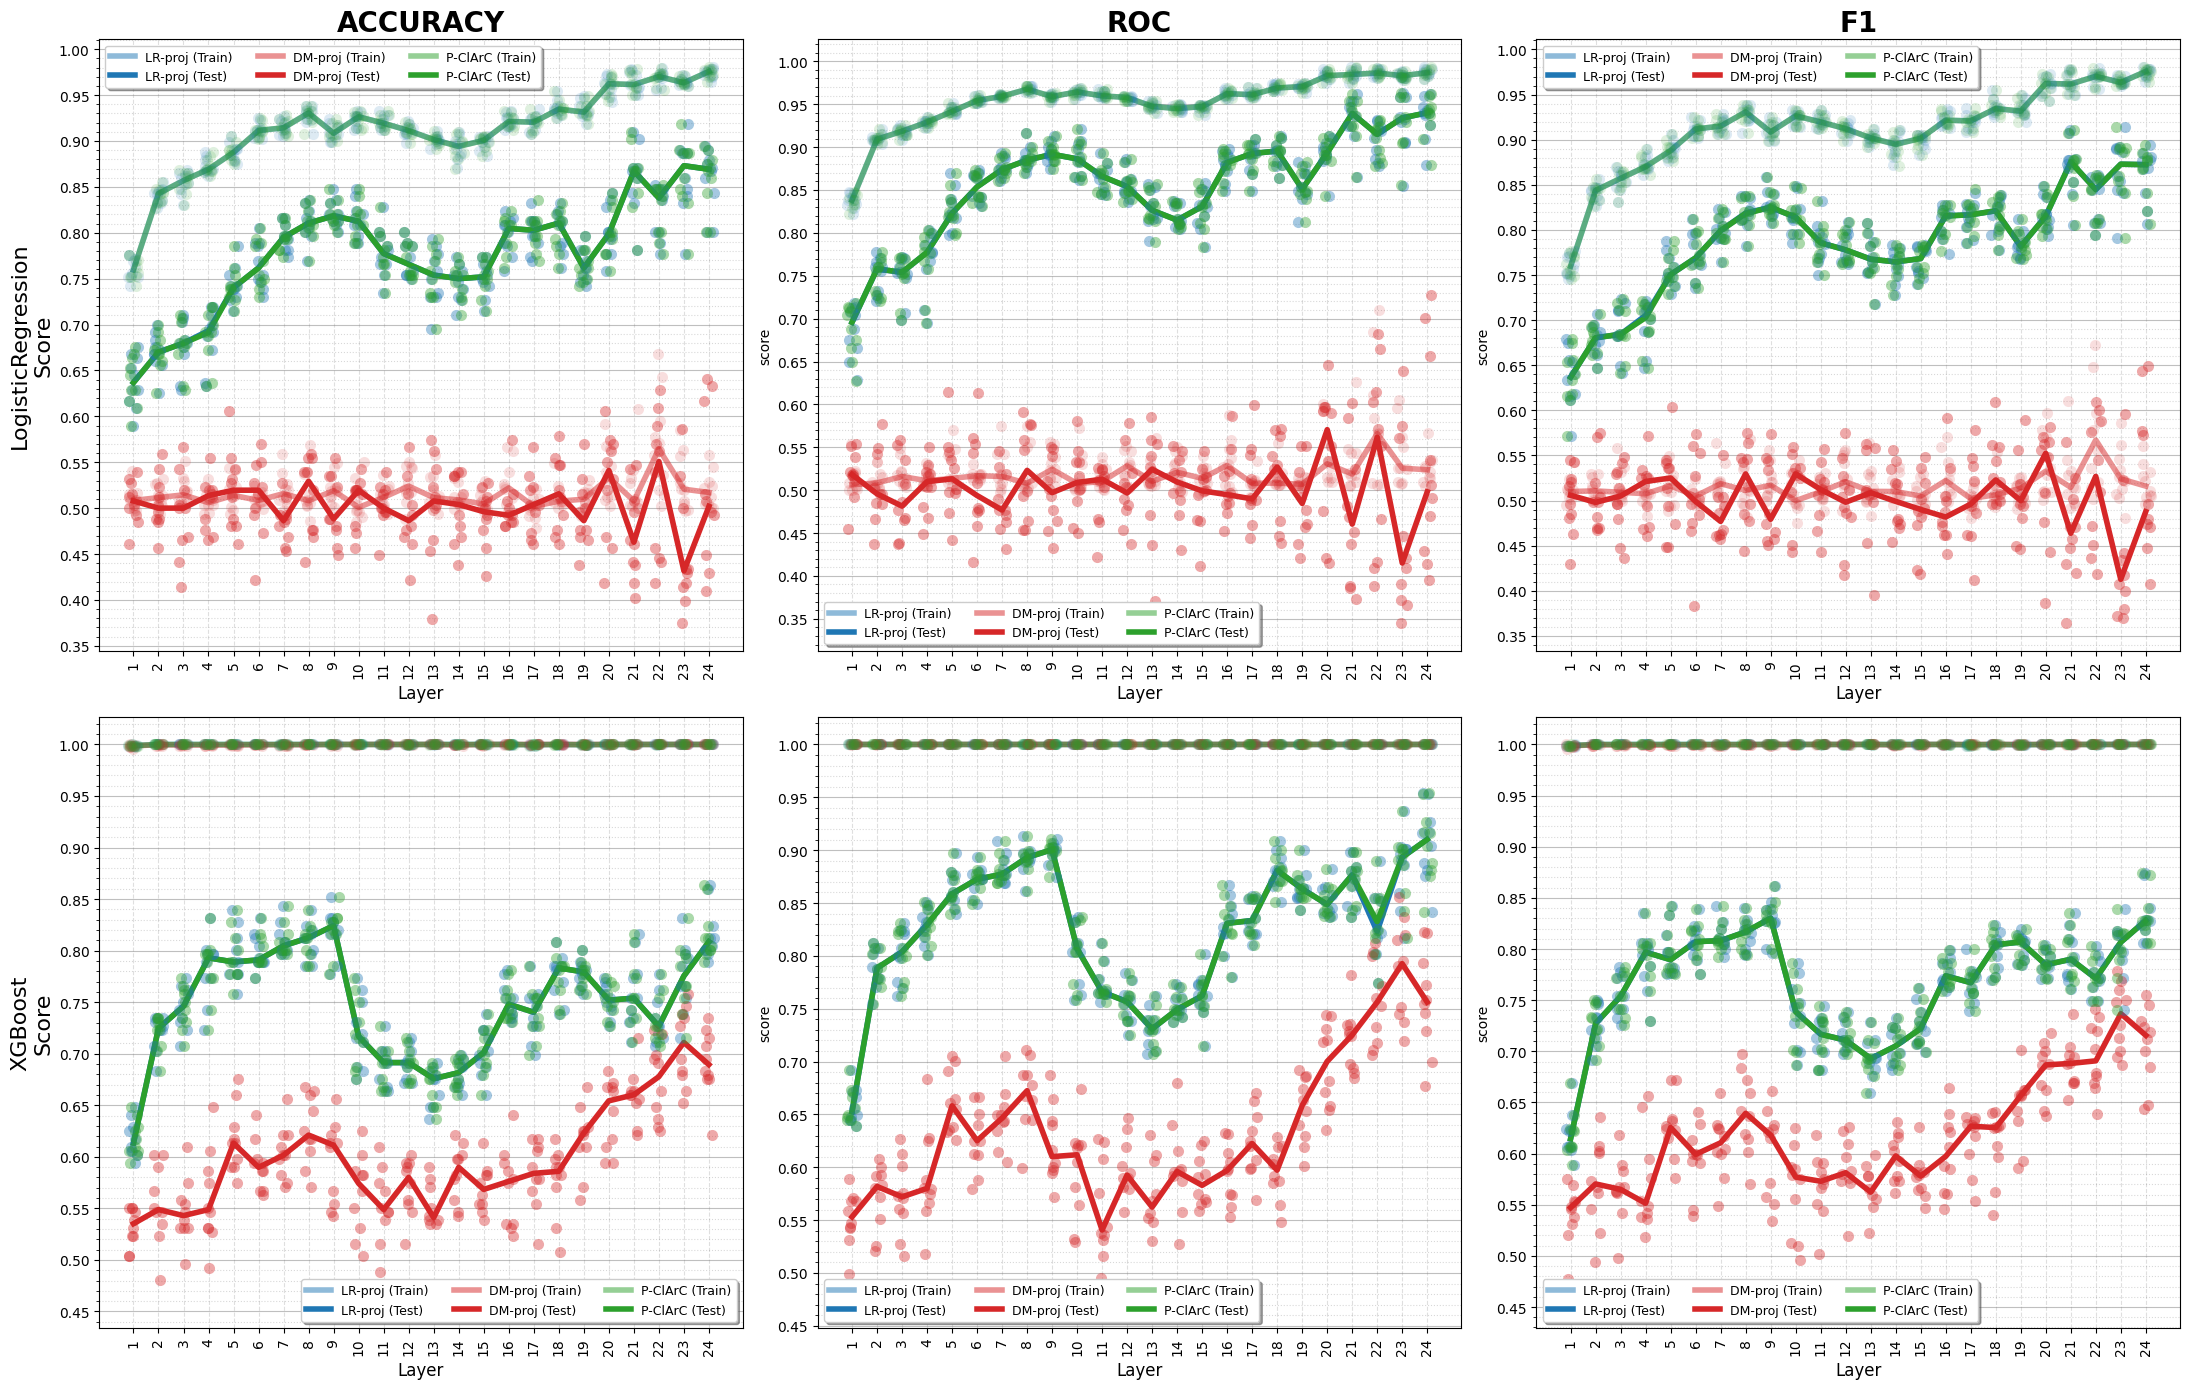

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# --- KONFIGURACJA STYLÓW ---
# Bazowe kolory zależą TYLKO od metody debiasingu
colors = {
    'lr':     '#1f77b4',  # Niebieski — ortogonalne rzutowanie CAV-LR
    'dm':     '#d62728',  # Czerwony — ortogonalne rzutowanie Difference-of-Means
    'pclarc': '#2ca02c',  # Zielony — P-ClArC (distribution shift)
}

# Sterujemy widocznością (alpha) w zależności od zbioru
alpha_points = {'train': 0.15, 'test': 0.4}
alpha_lines  = {'train': 0.5, 'test': 1.0}

methods_to_plot = [m for m in ['lr', 'dm', 'pclarc'] if m in df_melted['debias_method'].unique()]

df_plot = df_melted.copy()

fig, axes = plt.subplots(len(models), len(metrics), figsize=(22, 7 * len(models)))
if len(models) == 1: axes = np.expand_dims(axes, axis=0)

for r, model in enumerate(models):
    for c, metric in enumerate(metrics):
        ax = axes[r, c]

        layer_indices = sorted(df_plot['layer_id'].unique())

        for method in methods_to_plot:
            for subset in ['train', 'test']:
                data = df_plot[(df_plot['model'] == model) &
                               (df_plot['metric'] == metric) &
                               (df_plot['subset'] == subset) &
                               (df_plot['debias_method'] == method)]

                sns.stripplot(data=data, x='layer_id', y='score', color=colors[method],
                              alpha=alpha_points[subset], jitter=0.2, size=8, ax=ax)

                sns.lineplot(data=data, x='layer_id', y='score', color=colors[method],
                             estimator=np.median, errorbar=None, linewidth=4, ax=ax,
                             alpha=alpha_lines[subset], linestyle='-')

        ax.set_xticks(range(len(layer_indices)))
        ax.set_xticklabels([str(i + 1) for i in layer_indices], rotation=90)
        ax.set_xlabel("Layer", fontsize=12)

        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
        ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.5, color='gray')
        ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.3, color='gray')
        ax.grid(True, axis='x', linestyle='--', alpha=0.4)

        # --- LEGENDA: Train (jaśniej) + Test (pełny) dla każdej metody ---
        method_label = {'lr': 'LR-proj', 'dm': 'DM-proj', 'pclarc': 'P-ClArC'}
        custom_lines, labels = [], []
        for m in methods_to_plot:
            for s in ['train', 'test']:
                custom_lines.append(plt.Line2D([0], [0], color=colors[m], lw=4, alpha=alpha_lines[s]))
                labels.append(f"{method_label[m]} ({s.capitalize()})")

        ax.legend(custom_lines, labels,
                  loc='best',
                  frameon=True,
                  shadow=True,
                  prop={'size': 9},
                  ncol=len(methods_to_plot))

        if r == 0: ax.set_title(metric.upper(), fontsize=20, fontweight='bold')
        if c == 0: ax.set_ylabel(f"{model}\nScore", fontsize=16)

plt.tight_layout()
plt.savefig('../plots/eyeglasses_debiased_concept_detection_torch.png', bbox_inches='tight')
plt.show()